# Value Iteration

**Series:** RL from scratch · Model-Based Learning · Part 2  

In this notebook I solve FrozenLake with value iteration: instead of evaluating a policy and then improving it, I directly iterate the Bellman optimality equation until I get the optimal values, and only read off the policy at the end. I also go through **why** this is guaranteed to work, using contraction mappings and the Banach fixed-point theorem.

If you're only here for the implementation, feel free to skip section 4 (the theory) and jump straight to section 5. I didn't want to leave out any of the "whys", so that this can be a resource to come back to later.

**Contents**
1. Recap: policy iteration and its cost
2. The value iteration update
3. Value iteration = policy iteration with one evaluation sweep
4. Why it converges: contraction and the Banach fixed-point theorem
5. Setup
6. One-step lookahead
7. Value iteration
8. Extracting the policy
9. Running it: deterministic and slippery
10. Policy iteration vs value iteration

## 1. Recap: policy iteration and its cost

$$
\text{Evaluation:}\quad v_{k+1}(s) = \sum_a \pi(a \mid s) \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v_k(s')\big] \quad \text{(repeat until converged)}
$$

$$
\text{Improvement:}\quad \pi'(s) = \arg\max_a \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v_\pi(s')\big]
$$

In policy iteration, every single improvement step needs a **full** policy evaluation, i.e. sweeping over all states again and again until $V$ converges, just to then change a few actions. On slippery 8×8 FrozenLake that was 11 improvement steps but around 3,500 evaluation sweeps in total.

So the question is: do I really need the exact values of every intermediate policy? I only care about the **optimal** one.

## 2. The value iteration update

Skip the policy. Turn the Bellman optimality equation directly into an update:

$$
v_{k+1}(s) = \max_a \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v_k(s')\big] = \max_a Q_k(s, a)
$$

Start from $v_0 = 0$, sweep until $v$ stops changing, then read off the policy once at the end:

$$
\pi_*(s) = \arg\max_a \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v_*(s')\big]
$$

It looks almost the same as the policy evaluation update, with one key difference:
- **Policy evaluation:** average over the actions **the policy** picks, i.e. find the values of a fixed policy.
- **Value iteration:** take the **best** action at every state, i.e. find the optimal values directly, without fixing any policy.

So no policy is needed to start: just $V = 0$. At every state I compute Q for every action using the current $V$, and keep the biggest one.

## 3. Value iteration = policy iteration with one evaluation sweep

Do one improvement step, then just one evaluation sweep. Improving picks $\pi(s) = \arg\max_a Q_v(s,a)$, and one sweep for that policy sets:

$$
v(s) \leftarrow Q_v\big(s, \pi(s)\big) = \max_a Q_v(s, a)
$$

which is exactly the value iteration update. The max is the improvement step folded into every sweep.

Imagine I get impatient in policy iteration: instead of evaluating until convergence, I do **one** sweep, then improve, then one sweep, then improve, and keep the current $V$ between rounds instead of restarting from 0.

The improvement picks the action with the largest Q, and the one sweep then sets $V(s)$ to the Q of that action, which is just the max Q. The two steps merge into one update, and that update is value iteration.

So value iteration never needs to store a policy: at every sweep the policy is implicitly "whatever action wins the max". I only write it down at the end.

## 4. Why it converges: contraction and the Banach fixed-point theorem

Define the Bellman optimality operator $T$:

$$
(Tv)(s) = \max_a \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v(s')\big], \qquad v_* = T v_*
$$

$T$ is a $\gamma$-contraction in the max-norm:

$$
\|Tu - Tv\|_\infty \le \gamma\, \|u - v\|_\infty
$$

So by Banach, $v_*$ is the unique fixed point, value iteration reaches it from any start, and:

$$
\|v_k - v_*\|_\infty \le \gamma^k\, \|v_0 - v_*\|_\infty
$$

**Stopping rule** (only uses things we can compute):

$$
\|v_{k+1} - v_*\|_\infty \le \frac{\gamma}{1 - \gamma}\, \|v_{k+1} - v_k\|_\infty
$$

The rest of this section builds this up step by step.

### 4.1 The problem: why we need a theorem at all

The Bellman optimality equation is a system of $|\mathcal{S}|$ equations in $|\mathcal{S}|$ unknowns, one per state, and the **max makes it nonlinear**, so I can't invert a matrix like I can for a fixed policy. That raises three questions:

1. **Existence:** does a solution even exist?
2. **Uniqueness:** is there only one? If there were two, which one would be "optimal"?
3. **Computation:** how do I actually find it?

The contraction mapping / Banach fixed-point theorem answers all three at once.

### 4.2 The Bellman operator: turning the equation into a machine

Look at the Bellman optimality equation again:

$$
v_*(s) = \max_a \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v_*(s')\big]
$$

The value of a state depends on the values of the **next states** $s'$ (the places I can land in). But I don't know $v_*$, that's the whole problem.

So here's the trick: take **any guess** $v$, one number per state (e.g. all zeros, which is a terrible guess), and plug it in wherever the right-hand side needs a next-state value. The left-hand side then just becomes a **new number** for state $s$. Doing this for every state gives a new vector, called $Tv$:

$$
(Tv)(s) = \max_a \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, \underbrace{v(s')}_{\text{my current guess for where I land}}\big]
$$

So $T$ is a machine: **vector of guesses in → new vector of guesses out**. For each state, it does a one-step lookahead: real reward for the next step + γ × my current guess for wherever I land, and takes the best action.

**Tiny example** (deterministic lake, states 13 → 14 → goal, γ = 0.99, Right from 14 into the goal gives reward 1), starting from the guess $v = 0$:

| State | Input guess $v$ | $Tv$ | $T(Tv)$ |
|---|---|---|---|
| 14 | 0 | $1 + 0.99 \times 0 = 1$ | $1$ |
| 13 | 0 | $0 + 0.99 \times v(14) = 0$ | $0 + 0.99 \times 1 = 0.99$ |

- First application: 13 looks ahead to 14, but uses the **guess** for 14, which is still 0, so it learns nothing yet.
- Second application: the guess for 14 is now 1, so 13 picks it up and becomes 0.99.
- Third application: nothing changes, output = input.

That last point is the key. If I feed in the true values $v_*$, the output is exactly the same vector, because that's literally what the Bellman optimality equation says:

$$
v_* = T v_*
$$

A vector that $T$ leaves unchanged is called a **fixed point** of $T$. So solving the Bellman optimality equation = finding the fixed point of $T$. And repeatedly applying $T$ to a guess (exactly what value iteration does) is how we get there.

The same works for a fixed policy with the Bellman expectation operator, where instead of the best action I average over the actions the policy picks:

$$
(T^\pi v)(s) = \sum_a \pi(a \mid s) \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v(s')\big], \qquad v_\pi = T^\pi v_\pi
$$

### 4.3 Fixed points: the 1-D picture

A fixed point of a function $f$ is a point $x^*$ where $f(x^*) = x^*$. On a graph, it's where the curve $y = f(x)$ crosses the diagonal $y = x$. The simplest way to find one is to just keep applying $f$: $x_0 \to f(x_0) \to f(f(x_0)) \to \dots$

Toy example: $T(v) = 0.5v + 2$, so the fixed point is $v^* = 4$ (since $0.5 \times 4 + 2 = 4$).

| Step k | Start at 0 | Error | Start at 6 | Error |
| --- | --- | --- | --- | --- |
| 0 | 0 | 4 | 6 | 2 |
| 1 | 2 | 2 | 5 | 1 |
| 2 | 3 | 1 | 4.5 | 0.5 |
| 3 | 3.5 | 0.5 | 4.25 | 0.25 |
| 4 | 3.75 | 0.25 | 4.125 | 0.125 |

Both starts end up at 4, and the error **halves** every step because the slope is 0.5. If the slope were steeper than 1, the error would grow and the iteration would blow up.

In the cobweb plot below, each vertical step applies $T$ and each horizontal step goes back to the diagonal so the output becomes the next input. With slope < 1 the staircase spirals into the fixed point.

In [5]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

np.random.seed(0)

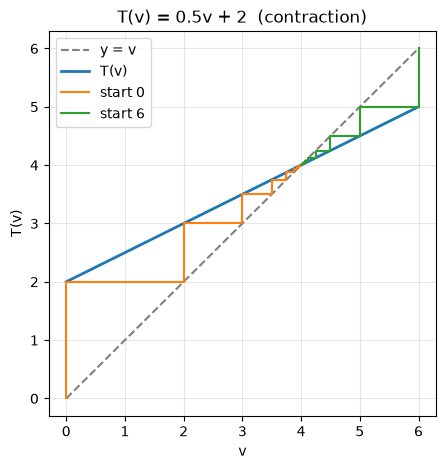

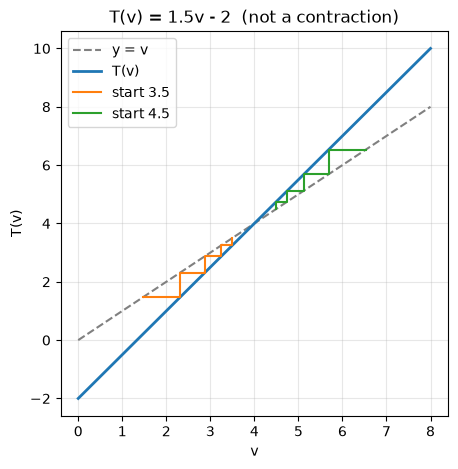

In [6]:
def cobweb(f, starts, x_range=(0, 6), steps=8, title=""):
    """Cobweb plot: iterate x -> f(x) from each start and draw the staircase."""
    xs = np.linspace(*x_range, 200)
    plt.figure(figsize=(5, 5))
    plt.plot(xs, xs, "--", color="gray", label="y = v")
    plt.plot(xs, f(xs), lw=2, label="T(v)")
    for x0 in starts:
        x, px, py = x0, [x0], [x0]
        for _ in range(steps):
            y = f(x); px += [x, y]; py += [y, y]; x = y
        plt.plot(px, py, lw=1.5, label=f"start {x0}")
    plt.xlabel("v"); plt.ylabel("T(v)"); plt.title(title); plt.legend(); plt.grid(alpha=.3); plt.show()

# contraction (slope 0.5): both starts converge to 4
cobweb(lambda v: 0.5 * v + 2, starts=[0, 6], title="T(v) = 0.5v + 2  (contraction)")

# not a contraction (slope 1.5): the staircase runs away from the fixed point
cobweb(lambda v: 1.5 * v - 2, starts=[3.5, 4.5], x_range=(0, 8), steps=4, title="T(v) = 1.5v - 2  (not a contraction)")

That "slope less than 1" idea is exactly what a contraction is. The next part makes it precise for vectors.

### 4.4 Contraction mappings and the max-norm

To talk about "closer" for value functions, I need a distance. The one that works here is the **max-norm**, i.e. the worst-case gap across all states:

$$
\|u - v\|_\infty = \max_s |u(s) - v(s)|
$$

$T$ is a **γ-contraction** if, for some $\gamma \in [0, 1)$ and **every** pair of vectors $u, v$:

$$
\|Tu - Tv\|_\infty \le \gamma\, \|u - v\|_\infty
$$

In words: take any two guesses, push both through $T$, and they come out at least a factor γ closer. $T$ basically squeezes the whole space. In the 1-D toy, $|T(u) - T(v)| = 0.5|u - v|$, so it's a contraction with γ = 0.5.

### 4.5 The Banach fixed-point theorem

If $T$ is a γ-contraction on a complete metric space (here: vectors with the max-norm, which is complete), then:

1. $T$ has **exactly one** fixed point $x^*$.
2. From **any** starting point $x_0$, iterating $x_{k+1} = T(x_k)$ converges to $x^*$.
3. The error shrinks geometrically: $\|x_k - x^*\| \le \gamma^k \|x_0 - x^*\|$.

**Why it's unique (one line).** Suppose $u$ and $v$ are both fixed points. Then

$$
\|u - v\| = \|Tu - Tv\| \le \gamma\, \|u - v\|
$$

Since γ < 1, the only number that's at most γ times itself is 0. So $u = v$.

**Why the error shrinks by γ each step.**

$$
\|x_k - x^*\| = \|T x_{k-1} - T x^*\| \le \gamma\, \|x_{k-1} - x^*\| \le \dots \le \gamma^k\, \|x_0 - x^*\|
$$

- **First `=`:** the update is $x_k = Tx_{k-1}$, and $x^*$ is a fixed point so $x^* = Tx^*$. Swap both in.
- **First `≤`:** the contraction property with $u = x_{k-1}$, $v = x^*$: pushing both through $T$ brings them at least γ closer.
- **The chain:** repeat the same step back to $x_0$. Each step adds a factor of γ, so after $k$ steps it's $\gamma^k$.

E.g. with $T(v) = 0.5v + 2$ from 0, the error goes $4 \to 2 \to 1 \to 0.5$.

**Why a fixed point exists (the part that needs completeness).** The part above assumed $x^*$ exists. Here's why it does, using only the iterates.

**a) Steps shrink geometrically.** Same trick on two consecutive iterates, with $d = \|x_1 - x_0\|$:

$$
\|x_{k+1} - x_k\| = \|Tx_k - Tx_{k-1}\| \le \gamma\, \|x_k - x_{k-1}\| \le \dots \le \gamma^k d
$$

**b) Distance between far-apart iterates.** Going from $x_n$ to $x_m$ ($m > n$) passes through all the iterates in between. By the triangle inequality, the direct distance is at most the total length of those steps:

$$
\|x_m - x_n\| \le \sum_{j=n}^{m-1} \|x_{j+1} - x_j\| \le \sum_{j=n}^{m-1} \gamma^j d
$$

**c) Geometric series.** The finite sum is at most the infinite one, and $1 + \gamma + \gamma^2 + \dots = \frac{1}{1-\gamma}$:

$$
\sum_{j=n}^{m-1} \gamma^j d \;\le\; \gamma^n d\,(1 + \gamma + \gamma^2 + \dots) = \frac{\gamma^n}{1-\gamma}\, d \;\to\; 0 \quad \text{as } n \to \infty
$$

I don't know $x^*$ yet, so I can't measure "distance to the answer". All I can do is compare the iterates **with each other**. The argument goes: the iterates get trapped in smaller and smaller boxes (d) → those boxes close in on exactly one point (e) → that point is a fixed point of $T$ (f).

**d) The iterates get trapped in shrinking boxes (Cauchy).** From step c: once I'm at $x_n$, every later iterate is within distance $r_n = \frac{\gamma^n}{1-\gamma}\, d$ of $x_n$, however far I keep going. So after step $n$, the rest of the sequence is trapped in a box of radius $r_n$ around $x_n$, and since $\gamma^n \to 0$, these boxes keep shrinking.

Toy example ($d = 2$, γ = 0.5):

| n | $x_n$ | radius $r_n = \frac{0.5^n}{0.5} \times 2$ | all later iterates trapped in |
|---|---|---|---|
| 1 | 2 | 2 | [0, 4] |
| 2 | 3 | 1 | [2, 4] |
| 3 | 3.5 | 0.5 | [3, 4] |
| 4 | 3.75 | 0.25 | [3.5, 4] |

A sequence whose tail gets trapped in smaller and smaller boxes like this is called **Cauchy**. Note that I never used $x^*$ to show this, only the iterates themselves.

**e) The boxes close in on one point (completeness).** The boxes keep shrinking towards size 0, and each one traps everything after it. So they close in on a single point. In the table, every box contains 4, and they shrink to just 4. That point is the limit, so I call it $x^*$.

The only thing that could go wrong is if that point were **missing from the space**, i.e. the boxes close in on a "hole". "Complete" means the space has no holes. Vectors of real numbers are complete, so the point always exists.

(Example of a space with holes: rational numbers only, i.e. fractions. The sequence 1, 1.4, 1.41, 1.414, … gets trapped in shrinking boxes around √2, but √2 isn't a fraction, so within the rationals the sequence has nowhere to land.)

**f) That point is a fixed point.** Look at the sequence of outputs $T(x_0), T(x_1), T(x_2), \dots$ in two ways:
- It's just the sequence shifted by one, since $T(x_k) = x_{k+1}$. So it heads to the same limit: $x^*$.
- Since $x_k$ gets close to $x^*$, and $T$ never pushes points further apart ($\|T(x_k) - T(x^*)\| \le \gamma\, \|x_k - x^*\|$), the outputs $T(x_k)$ get close to $T(x^*)$. So it heads to $T(x^*)$.

One sequence can't head to two different points, so $T(x^*) = x^*$. The limit is a fixed point.

Toy example: the outputs $T(0), T(2), T(3), T(3.5), \dots = 2, 3, 3.5, 3.75, \dots$ head to 4, and $T(4) = 0.5 \times 4 + 2 = 4$. ✓

Important: the theorem is general and knows nothing about MDPs. To use it for RL, I still have to **prove** that the Bellman operator is a contraction.

### 4.6 Proof: the Bellman optimality operator is a γ-contraction

So what I want to show is that for **any** two guesses $u$ and $v$, one application of $T$ brings them at least γ closer:

$$
\|Tu - Tv\|_\infty \le \gamma\, \|u - v\|_\infty
$$

The idea is basically to follow the gap between $u$ and $v$ as it goes through each part of $T$: the reward, the average over next states, the max over actions and the discount γ, and check what each part does to it.

**First, a small fact: taking the max can't make a gap bigger.**

Say I have two scoreboards over the same actions, $f = [3, 7, 5]$ and $g = [4, 6, 5.5]$. Entry by entry they differ by at most 1. Their top scores are 7 and 6, which also differ by 1, not more. That's always true: if every entry differs by at most δ, the top scores can't differ by more than δ.

$$
\Big|\max_a f(a) - \max_a g(a)\Big| \le \max_a |f(a) - g(a)|
$$

Why: say $f$ has the bigger max, and $a^*$ is the action where $f$ hits it. $g$'s best is at least $g(a^*)$, so

$$
\max_a f(a) - \max_a g(a) \;\le\; f(a^*) - g(a^*) \;\le\; \max_a |f(a) - g(a)|
$$

i.e. the gap between the two maxes is at most the gap at one particular action, which is at most the biggest gap. (If $g$ has the bigger max, same thing with $f$ and $g$ swapped.)

**Now the main proof.** Let me write the inside of $T$ as a Q value built from a guess $v$:

$$
Q_v(s, a) = \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v(s')\big], \qquad (Tv)(s) = \max_a Q_v(s, a)
$$

Now I pick any state $s$ and follow the gap between $(Tu)(s)$ and $(Tv)(s)$.

**Step 1: the max can't make the gap bigger.** Using the small fact above, the gap after the max is at most the biggest gap between the Q values:

$$
|(Tu)(s) - (Tv)(s)| = \Big|\max_a Q_u(s,a) - \max_a Q_v(s,a)\Big| \le \max_a |Q_u(s,a) - Q_v(s,a)|
$$

**Step 2: the rewards cancel out.** $Q_u$ and $Q_v$ use the exact same rewards; the only difference is which guess I plug in for the next state. So when I subtract, the $r$'s cancel and only the guesses are left:

$$
Q_u(s,a) - Q_v(s,a) = \gamma \sum_{s',r} p(s',r \mid s,a)\,\big[u(s') - v(s')\big]
$$

**Step 3: an average can't beat the worst case.** The sum is basically a weighted average of the gaps $u(s') - v(s')$ over the places I could land. An average of gaps can't be bigger than the biggest gap, which is exactly $\|u - v\|_\infty$:

$$
|Q_u(s,a) - Q_v(s,a)| \le \gamma \sum_{s',r} p(s',r \mid s,a)\,|u(s') - v(s')| \le \gamma\, \|u - v\|_\infty \underbrace{\sum_{s',r} p(s',r \mid s,a)}_{=\,1}
$$

(The probabilities add up to 1, so I'm left with just $\gamma\, \|u - v\|_\infty$.)

**Step 4: this works for every state.** Steps 1 to 3 hold for every action and every state $s$, so the biggest gap over all states is also at most $\gamma\, \|u - v\|_\infty$:

$$
\|Tu - Tv\|_\infty \le \gamma\, \|u - v\|_\infty \qquad \blacksquare
$$

**So basically, here's what each part of $T$ does to the gap:**

| Part of $T$ | What it does to the gap |
| --- | --- |
| Rewards $r$ | Cancel out, they're the same for both guesses |
| Average over next states $s'$ | Averages the gaps, so the worst gap can't get bigger |
| Max over actions | Can't make it bigger either (the scoreboard fact) |
| Discount γ | The only part that actually shrinks it, by a factor γ < 1 |

Everything else just passes the gap through without growing it, and γ is the one thing that squeezes it. That's why γ < 1 is so important here.

The same proof works for the Bellman expectation operator $T^\pi$, just without Step 1: instead of a max over actions, it's an average over $\pi(a \mid s)$, which also can't make the gap bigger. So policy evaluation converges for the same reason.

### 4.7 What this gives me

1. **Existence and uniqueness:** there's exactly one $v_*$ solving the Bellman optimality equation. No ambiguity about what "optimal" means.
2. **Value iteration works:** start from **any** guess (all zeros, random, anything) and keep applying $T$; it converges to $v_*$.
3. **Convergence rate:** the error shrinks by at least γ every sweep. For γ = 0.9, since $0.9^{22} \approx 0.1$, every ~22 sweeps gives roughly one more correct decimal digit.
4. **Practical stopping rule:** I don't know $v_*$, so I can't measure the error directly. But with the triangle inequality:

$$
\|v_k - v_*\| \le \|v_k - v_{k+1}\| + \|v_{k+1} - v_*\| \le \|v_k - v_{k+1}\| + \gamma\, \|v_k - v_*\|
$$

Rearranging gives $\|v_k - v_*\| \le \frac{1}{1-\gamma}\|v_{k+1} - v_k\|$, and one more application of the contraction gives the stopping rule above. So if two consecutive sweeps differ by less than $\varepsilon(1-\gamma)/\gamma$, I'm within ε of the true answer.

### 4.8 Intuitions to remember

- **The whole chain in one line:** Bellman optimality equation ⇔ $v_* = Tv_*$; $T$ is a γ-contraction; so by Banach, $v_*$ exists, is unique, and $T^k v_0 \to v_*$ from any $v_0$.
- **Value iteration as a growing horizon:** $v_k = T^k v_0$ is the best I can do if I act optimally for $k$ steps and then get $v_0$ as a final payoff. My initial guess only shows up after $k$ steps, weighted by $\gamma^k$, so it gets forgotten at exactly the contraction rate.
- **Why γ < 1 matters:** in the proof, γ was the only thing that actually shrank the gap. With γ = 1 it's not a contraction in general and the argument breaks (episodic tasks that always terminate need a separate argument).
- **Why the max-norm:** Step 3 used "a weighted average is at most the worst case", which is a max-norm statement. In other norms like L2, $T$ isn't guaranteed to be a contraction. This matters later with function approximation.
- **What contraction means physically:** two agents with different beliefs each do one step of honest lookahead. The real reward they see is identical, only the discounted belief about the future differs, so their disagreement shrinks. Repeat, and everyone ends up at $v_*$.

## 5. Setup

### Helpers (pre-written, not the focus)

In [7]:
ARROWS = ["←", "↓", "→", "↑"]
ACTION_NAMES = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}

def print_board(env, state):
    """Text view of the lake; A = agent, S = start, F = frozen, H = hole, G = goal."""
    desc = env.unwrapped.desc.astype(str).copy()
    r, c = divmod(int(state), desc.shape[1])
    desc[r, c] = "A"
    print("\n".join(" ".join(row) for row in desc), "\n")

def show_policy(policy, values=None, env=None, title="Policy"):
    """Grid with policy arrows. values = V (one per state) or Q (states x actions, max is shown)."""
    desc = env.unwrapped.desc.astype(str)
    n_rows, n_cols = desc.shape
    policy = np.asarray(policy).astype(int)
    if values is None:
        grid = np.zeros((n_rows, n_cols))
    else:
        values = np.asarray(values)
        grid = (values.max(axis=1) if values.ndim == 2 else values).reshape(n_rows, n_cols)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(grid, cmap="viridis", vmin=min(0, grid.min()), vmax=max(grid.max(), 1e-8))
    for s in range(n_rows * n_cols):
        r, c = divmod(s, n_cols)
        cell = desc[r, c]
        if cell == "H":
            ax.add_patch(plt.Rectangle((c - .5, r - .5), 1, 1, color="black"))
            ax.text(c, r, "H", ha="center", va="center", color="red", fontsize=14)
        elif cell == "G":
            ax.text(c, r, "G", ha="center", va="center", color="gold", fontsize=16, weight="bold")
        else:
            ax.text(c, r - .05, ARROWS[policy[s]], ha="center", va="center", color="white", fontsize=18)
            if values is not None:
                ax.text(c, r + .32, f"{grid[r, c]:.2f}", ha="center", va="center", color="white", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)
    plt.show()

def plot_curve(y, title="", xlabel="", ylabel="", smooth=None, logy=False):
    """Line plot; smooth = moving-average window (optional); logy = log scale on y."""
    y = np.asarray(y, dtype=float)
    plt.figure(figsize=(6, 3))
    if smooth:
        plt.plot(y, alpha=.25)
        y = np.convolve(y, np.ones(smooth) / smooth, mode="valid")
    plt.plot(y)
    if logy: plt.yscale("log")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.grid(alpha=.3); plt.show()

In [8]:
# deterministic and slippery FrozenLake 4x4
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
env_slip = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)

## 6. One-step lookahead

Both value iteration and policy extraction need the Q value of every action from a state, given $V$:

$$
Q(s, a) = \sum_{(p,\, s',\, r) \in P[s][a]} p\,\big[r + \gamma\, V(s')\big]
$$

This is the "one-step lookahead": for each action, look at every place I could land, and average reward + discounted value of landing there.

In [9]:
def one_step_lookahead(env, V, s, gamma=0.99):
    # array of Q values, one per action
    Q = np.zeros(env.action_space.n)
    mdp = env.unwrapped.P

    
    # for each action
    for action in range(env.action_space.n):
        # sum over outcomes: p * (r + gamma * V[s_next])
        possible_outcomes = mdp[s][action]
        for p, next_s, reward, terminated in possible_outcomes:
            Q[action] += p * (reward + gamma*V[next_s])
        

    # return the array
    return Q

In [10]:
# sanity check: with V = 0, only "Right" from state 14 earns anything (reward 1)
q = one_step_lookahead(env, np.zeros(16), 14)
assert np.allclose(q, [0, 0, 1, 0]), q
print("one_step_lookahead ✓", q)

one_step_lookahead ✓ [0. 0. 1. 0.]


### Checking the contraction numerically

Applying $T$ to a whole vector = one value iteration sweep. If $T$ really is a γ-contraction, then for **any** two random vectors $u, v$ the ratio $\|Tu - Tv\|_\infty / \|u - v\|_\infty$ should never go above γ.

In [11]:
def bellman_operator(env, V, gamma=0.99):
    # (TV)(s) = max over actions of the one-step lookahead
    return np.array([one_step_lookahead(env, V, s, gamma).max() for s in range(env.observation_space.n)])

# try many random pairs of value vectors on the slippery lake
gamma = 0.9
ratios = []
for _ in range(1000):
    u, v = np.random.randn(16) * 5, np.random.randn(16) * 5
    ratios.append(np.max(np.abs(bellman_operator(env_slip, u, gamma) - bellman_operator(env_slip, v, gamma)))
                  / np.max(np.abs(u - v)))

print(f"largest ratio seen: {max(ratios):.4f}  (gamma = {gamma})")

largest ratio seen: 0.9000  (gamma = 0.9)


**What I see:** the largest ratio comes out at γ = 0.9 and never above it. So every application of $T$ squeezes any two guesses at least 10% closer, exactly what the proof says, and the bound is tight: some pairs of guesses get squeezed by exactly γ, no more.

## 7. Value iteration

In [12]:
def value_iteration(env, gamma=0.99, max_iterations=10000, tol=1e-8):
    # V = zeros
    V = np.zeros(env.observation_space.n)

    # list to record the max change per sweep
    deltas = []

    # repeat
    for _ in range(max_iterations):
        # copy of old V
        V_old = V.copy()

        # for each state: V[s] = max of one_step_lookahead with the old V
        for s in range(env.observation_space.n):
            Q_s = one_step_lookahead(env, V, s, gamma)
            V[s] = np.max(Q_s)

        # record max change; stop if < tol
        deltas.append(np.max(np.abs(V_old-V)))

        if deltas[-1] < tol:
           break

    # return V, deltas
    return V, deltas

## 8. Extracting the policy

Once $V$ has converged to $v_*$, the optimal policy is just the greedy action from the one-step lookahead at every state.

In [13]:
def extract_policy(env, V, gamma=0.99):
    # greedy action per state using one_step_lookahead
    policy = np.zeros(env.observation_space.n)
    for s in range(env.observation_space.n):
        Q_s = one_step_lookahead(env, V, s, gamma)
        policy[s] = int(np.argmax(Q_s))

    return policy

## 9. Running it

### Deterministic lake

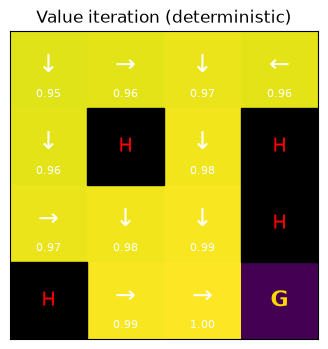

In [14]:
# value iteration + policy on the deterministic env
V, deltas = value_iteration(env)
policy = extract_policy(env, V)

# show policy with values
show_policy(policy, V, env, title="Value iteration (deterministic)")

In [15]:
# sanity check: same optimum as policy iteration → V(start) = gamma^5
assert np.isclose(V[0], 0.99 ** 5, atol=1e-6), V[0]
print("V(start) ✓", V[0], "| sweeps:", len(deltas))

V(start) ✓ 0.9509900498999999 | sweeps: 7


**What I see:** only 7 sweeps on the deterministic lake. The values spread **backwards from the goal**, one step per sweep: after sweep 1 only state 14 knows about the reward, after sweep 2 its neighbours do, and so on. The start is 6 steps away, so after about 6 sweeps the values stop changing (the 7th sweep confirms it). Same values and the same $V(\text{start}) = \gamma^5$ as policy iteration.

### Slippery lake

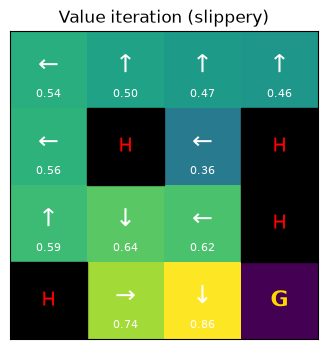

sweeps: 324


In [16]:
# value iteration + policy on the slippery env
V_slip, deltas_slip = value_iteration(env_slip)
policy_slip = extract_policy(env_slip, V_slip)

# show policy with values
show_policy(policy_slip, V_slip, env_slip, title="Value iteration (slippery)")
print("sweeps:", len(deltas_slip))

In [17]:
def test_policy(policy, env, num_episodes=1000):
    # count successes
    successes = 0

    # loop over episodes
    for _ in range(num_episodes):
        # reset env
        state, _ =env.reset()
        done = False

        # follow the policy until terminated or truncated
        while not done:
            action = int(policy[state])
            state, reward, terminated, truncated, _ =env.step(action)
            done = terminated or truncated


        # success if final reward == 1
        if reward == 1:
            successes+=1

    # print and return success rate
    success_rate = successes/num_episodes
    print(f"Success Rate: {success_rate}")
    return success_rate

In [ ]:
# success rate 
test_policy(policy_slip, env_slip)

Success Rate: 0.749


0.749

### Convergence

The contraction bound says the error shrinks by at least γ per sweep, which is a straight line on a log scale.

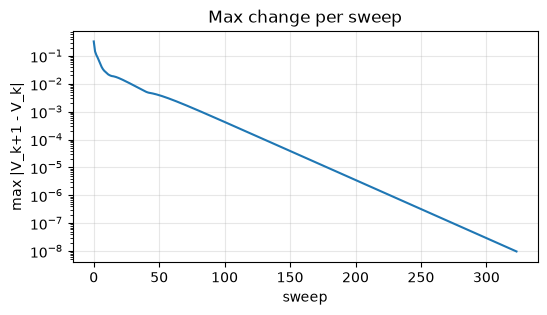

In [19]:
# plot max change per sweep on a log scale
plot_curve(deltas_slip, title="Max change per sweep", xlabel="sweep", ylabel="max |V_k+1 - V_k|", logy=True)

**What I see:**
- The slippery lake needs many more sweeps than the deterministic one, because the slipping keeps feeding value back and forth between states, so it takes longer to settle.
- On the log scale the curve becomes a straight line, i.e. geometric decay, as the contraction bound predicts. The slope is at most $\log \gamma$ per sweep (here it's actually a bit steeper, since terminal states have no future value).
- The stopping rule: with γ = 0.99 and tol = 1e-8, the final error is at most $\frac{0.99}{0.01} \times 10^{-8} \approx 10^{-6}$, which is plenty accurate.
- Same policy and roughly the same ~74% success rate as policy iteration, as it should be since both find $v_*$.

## 10. Policy iteration vs value iteration

|  | Policy iteration | Value iteration |
| --- | --- | --- |
| Equation used | Bellman **expectation** equation (evaluation) + greedy improvement | Bellman **optimality** equation |
| Starts from | A random policy | $V = 0$ (any $V$ works), no policy |
| Work per step | Full policy evaluation (many sweeps) + one improvement | One sweep with a max over actions |
| Number of steps | Few improvement steps, but many evaluation sweeps in total | Many cheap sweeps |
| When the policy appears | Every step (explicit policy the whole time) | Only at the end (greedy w.r.t. $v_*$) |
| Why it converges | Finitely many policies + each step improves | $T$ is a γ-contraction (Banach) |

**Key takeaways:**
- Value iteration skips full policy evaluation: start from $V = 0$ and repeatedly apply the Bellman optimality backup (max over actions), then read off the greedy policy at the end.
- The max does the improvement step inside every sweep, so value iteration is basically policy iteration with just one evaluation sweep between improvements.
- It's guaranteed to work because the Bellman optimality operator is a γ-contraction: by the Banach fixed-point theorem $v_*$ exists, is unique, and is reached from any starting guess, with the error shrinking by γ every sweep.
- In the proof, rewards cancel, averaging and max can't increase the gap, and γ is the only thing that shrinks it.

**Limitation → what's next:** both policy and value iteration need the full model $p(s', r \mid s, a)$. Model-free methods (Monte Carlo, TD learning) learn from experience instead, by actually playing the game.